In [2]:
# ── Kütüphane Kurulumu ──────────────────────────────────────
# Bu hücreyi bir kez çalıştır, oturum boyunca kurulu kalır

!pip install GEOparse pydeseq2 matplotlib seaborn pandas numpy scipy scikit-learn -q

print("✅ Kurulum tamamlandı!")

✅ Kurulum tamamlandı!


### **Bu kütüphaneler ne işe yarıyor?**

**GEOparse** → NCBI GEO veri tabanından doğrudan veri indirmek için. GEO dünyanın en büyük gen ekspresyon veri tabanı — binlerce gerçek hasta verisi var.

**pydeseq2** → Diferansiyel gen ekspresyon analizi için. "Bu gen hasta grubunda sağlıklıya göre anlamlı olarak farklı mı?" sorusunu istatistiksel olarak cevaplıyor.

**seaborn / matplotlib** → Volcano plot, heatmap, PCA grafikleri için.

**scipy / scikit-learn** → İstatistiksel testler ve PCA analizi için.

In [3]:
# ── Kütüphaneleri yükle ──────────────────────────────────────
import GEOparse
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print("✅ Kütüphaneler yüklendi!")

✅ Kütüphaneler yüklendi!


In [4]:
# ── GEO'dan veri indir ───────────────────────────────────────
# GSE48350: Alzheimer hastası vs sağlıklı beyin dokusu
# 253 örnek, prefrontal korteks bölgesi

print("📥 GEO'dan veri indiriliyor... (1-2 dakika sürebilir)")

gse = GEOparse.get_GEO(geo="GSE48350", destdir="./")

print(f"✅ Veri indirildi!")
print(f"📊 Örnek sayısı: {len(gse.gsms)}")
print(f"📋 Platform: {list(gse.gpls.keys())}")

13-Mar-2026 02:58:36 DEBUG utils - Directory ./ already exists. Skipping.
DEBUG:GEOparse:Directory ./ already exists. Skipping.
13-Mar-2026 02:58:36 INFO GEOparse - Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE48nnn/GSE48350/soft/GSE48350_family.soft.gz to ./GSE48350_family.soft.gz
INFO:GEOparse:Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE48nnn/GSE48350/soft/GSE48350_family.soft.gz to ./GSE48350_family.soft.gz


📥 GEO'dan veri indiriliyor... (1-2 dakika sürebilir)


100%|██████████| 151M/151M [00:02<00:00, 56.3MB/s]
13-Mar-2026 02:58:40 DEBUG downloader - Size validation passed
DEBUG:GEOparse:Size validation passed
13-Mar-2026 02:58:40 DEBUG downloader - Moving /tmp/tmpslg89rer to /content/GSE48350_family.soft.gz
DEBUG:GEOparse:Moving /tmp/tmpslg89rer to /content/GSE48350_family.soft.gz
13-Mar-2026 02:58:40 DEBUG downloader - Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE48nnn/GSE48350/soft/GSE48350_family.soft.gz
DEBUG:GEOparse:Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE48nnn/GSE48350/soft/GSE48350_family.soft.gz
13-Mar-2026 02:58:40 INFO GEOparse - Parsing ./GSE48350_family.soft.gz: 
INFO:GEOparse:Parsing ./GSE48350_family.soft.gz: 
13-Mar-2026 02:58:40 DEBUG GEOparse - DATABASE: GeoMiame
DEBUG:GEOparse:DATABASE: GeoMiame
13-Mar-2026 02:58:40 DEBUG GEOparse - SERIES: GSE48350
DEBUG:GEOparse:SERIES: GSE48350
13-Mar-2026 02:58:40 DEBUG GEOparse - PLATFORM: GPL570
DEBUG:GEOparse:PLATFORM: GPL570
13-Mar-2026 

✅ Veri indirildi!
📊 Örnek sayısı: 253
📋 Platform: ['GPL570']


In [7]:
# ── Etiket formatını kontrol et ──────────────────────────────
# İlk 5 örneğin characteristics_ch1 alanına bakalım

for gsm_id, gsm in list(gse.gsms.items())[:5]:
    print(f"{gsm_id}: {gsm.metadata['characteristics_ch1']}")

GSM300166: ['individual: 10, C', 'brain region: postcentral gyrus', 'gender: female', 'age (yrs): 91']
GSM300167: ['individual: 10, C', 'brain region: superior frontal gyrus', 'gender: female', 'age (yrs): 91']
GSM300168: ['individual: 105, C', 'brain region: hippocampus', 'gender: female', 'age (yrs): 96']
GSM300169: ['individual: 106, C', 'brain region: hippocampus', 'gender: male', 'age (yrs): 82']
GSM300170: ['individual: 108, C', 'brain region: hippocampus', 'gender: male', 'age (yrs): 84']


In [9]:
# ── Grupları tanımla ─────────────────────────────────────────
# Her örneğin Alzheimer (AD) mı yoksa Kontrol (C) mı olduğunu bul

hastalar = []   # Alzheimer
kontroller = [] # Sağlıklı

for gsm_id, gsm in gse.gsms.items():
    ozellik = gsm.metadata['characteristics_ch1'][0]  # 'individual: X, AD' veya 'individual: X, C'

    if ', AA' in ozellik:
        hastalar.append(gsm_id)
    elif ', C' in ozellik:
        kontroller.append(gsm_id)

print(f"🧠 Alzheimer hastası : {len(hastalar)} örnek")
print(f"✅ Sağlıklı kontrol  : {len(kontroller)} örnek")
print(f"📊 Toplam            : {len(hastalar) + len(kontroller)} örnek")

print(f"\n🔍 İlk 3 hasta örneği  : {hastalar[:3]}")
print(f"🔍 İlk 3 kontrol örneği: {kontroller[:3]}")

🧠 Alzheimer hastası : 33 örnek
✅ Sağlıklı kontrol  : 140 örnek
📊 Toplam            : 173 örnek

🔍 İlk 3 hasta örneği  : ['GSM300173', 'GSM300174', 'GSM300175']
🔍 İlk 3 kontrol örneği: ['GSM300166', 'GSM300167', 'GSM300168']


In [8]:
# ── Tüm unique etiketleri gör ────────────────────────────────
etiketler = set()
for gsm_id, gsm in gse.gsms.items():
    etiket = gsm.metadata['characteristics_ch1'][0]
    etiketler.add(etiket)

print(f"Toplam unique etiket: {len(etiketler)}")
print("\nÖrnek etiketler:")
for e in sorted(etiketler)[:20]:
    print(f"  {e}")

Toplam unique etiket: 59

Örnek etiketler:
  gender: female
  gender: male
  individual: 10, C
  individual: 105, C
  individual: 106, C
  individual: 108, C
  individual: 109, C
  individual: 111, C
  individual: 12, AA
  individual: 14, C
  individual: 15, C
  individual: 16-07, C
  individual: 17, C
  individual: 18, C
  individual: 2, C
  individual: 21, C
  individual: 26, C
  individual: 27, C
  individual: 28, C
  individual: 29, C


In [5]:
# ── Veriyi tanıyalım ─────────────────────────────────────────
# GSM = her bir hasta/kontrol örneği
# İlk örneğe bakalım

ilk_ornek = list(gse.gsms.values())[0]

print("📋 İlk örnek bilgileri:")
print(f"   Başlık    : {ilk_ornek.metadata['title'][0]}")
print(f"   Kaynak    : {ilk_ornek.metadata['source_name_ch1'][0]}")
print(f"   Özellikler: {ilk_ornek.metadata['characteristics_ch1']}")
print(f"\n📊 Gen sayısı: {len(ilk_ornek.table)}")
print(f"\n🔍 Veri tablosunun ilk 5 satırı:")
print(ilk_ornek.table.head())

📋 İlk örnek bilgileri:
   Başlık    : PostcentralGyrus_female_91yrs_indiv10
   Kaynak    : brain, postcentral gyrus, female, 91 years
   Özellikler: ['individual: 10, C', 'brain region: postcentral gyrus', 'gender: female', 'age (yrs): 91']

📊 Gen sayısı: 54675

🔍 Veri tablosunun ilk 5 satırı:
      ID_REF     VALUE     PLIER
0  1007_s_at  0.888016  0.954806
1    1053_at  0.666460  0.569716
2     117_at  0.859638  1.256914
3     121_at  0.975150  1.231059
4  1255_g_at  0.491255  0.746131


In [10]:
# ── Gen ekspresyon matrisi oluştur ───────────────────────────
# Her satır = bir gen, her sütun = bir örnek
# Sadece AA ve C örneklerini al

secilen_ornekler = hastalar + kontroller
print(f"📊 Kullanılacak örnek sayısı: {len(secilen_ornekler)}")
print("⏳ Matris oluşturuluyor... (biraz sürebilir)")

# Her örnekten VALUE sütununu al
matris = pd.DataFrame()

for gsm_id in secilen_ornekler:
    gsm = gse.gsms[gsm_id]
    matris[gsm_id] = gsm.table.set_index('ID_REF')['VALUE']

print(f"✅ Matris oluşturuldu!")
print(f"📐 Boyut: {matris.shape[0]} gen × {matris.shape[1]} örnek")
print(f"\n🔍 İlk 5 satır, ilk 4 sütun:")
print(matris.iloc[:5, :4])

📊 Kullanılacak örnek sayısı: 173
⏳ Matris oluşturuluyor... (biraz sürebilir)
✅ Matris oluşturuldu!
📐 Boyut: 54675 gen × 173 örnek

🔍 İlk 5 satır, ilk 4 sütun:
           GSM300173  GSM300174  GSM300175  GSM300176
ID_REF                                               
1007_s_at   0.524710   0.796570   0.596087   0.797422
1053_at     0.876624   0.917716   1.018177   1.104526
117_at      0.824494   1.650645   0.723152   0.820683
121_at      1.151515   0.960083   0.908892   1.169894
1255_g_at   1.422447   5.011413   1.330216   0.571128


In [11]:
# ── Etiket tablosu ───────────────────────────────────────────
# Her örnek için hasta mı kontrol mü olduğunu belirten tablo

etiketler = []
for gsm_id in secilen_ornekler:
    if gsm_id in hastalar:
        etiketler.append('Alzheimer')
    else:
        etiketler.append('Kontrol')

meta_df = pd.DataFrame({
    'ornekID' : secilen_ornekler,
    'grup'    : etiketler
}).set_index('ornekID')

print("📋 Etiket tablosu:")
print(meta_df['grup'].value_counts())
print(f"\n🔍 İlk 5 satır:")
print(meta_df.head())

📋 Etiket tablosu:
grup
Kontrol      140
Alzheimer     33
Name: count, dtype: int64

🔍 İlk 5 satır:
                grup
ornekID             
GSM300173  Alzheimer
GSM300174  Alzheimer
GSM300175  Alzheimer
GSM300176  Alzheimer
GSM300218  Alzheimer


In [12]:
# ── Veri temizleme ───────────────────────────────────────────
# Düşük ekspresyonlu genler gürültü yaratır — bunları çıkaralım
# Kural: tüm örneklerin %20'sinden fazlasında değeri 1'in altında olan genleri at

print(f"⚙️  Temizleme öncesi gen sayısı: {matris.shape[0]}")

# Eksik değerleri doldur
matris = matris.fillna(matris.median())

# Düşük ekspresyonlu genleri filtrele
esik = 1.0  # ekspresyon eşiği
min_ornek = matris.shape[1] * 0.20  # örneklerin %20'si

filtre = (matris > esik).sum(axis=1) >= min_ornek
matris_temiz = matris[filtre]

print(f"✅ Temizleme sonrası gen sayısı: {matris_temiz.shape[0]}")
print(f"🗑️  Çıkarılan gen sayısı        : {matris.shape[0] - matris_temiz.shape[0]}")

# Log2 normalizasyon — değerleri daha karşılaştırılabilir hale getirir
matris_log = np.log2(matris_temiz + 1)

print(f"\n📊 Ekspresyon değer aralığı (log2):")
print(f"   Min : {matris_log.min().min():.2f}")
print(f"   Max : {matris_log.max().max():.2f}")
print(f"   Ort : {matris_log.mean().mean():.2f}")

⚙️  Temizleme öncesi gen sayısı: 54675
✅ Temizleme sonrası gen sayısı: 39961
🗑️  Çıkarılan gen sayısı        : 14714

📊 Ekspresyon değer aralığı (log2):
   Min : 0.01
   Max : 10.27
   Ort : 1.02


In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = matris_log.T
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

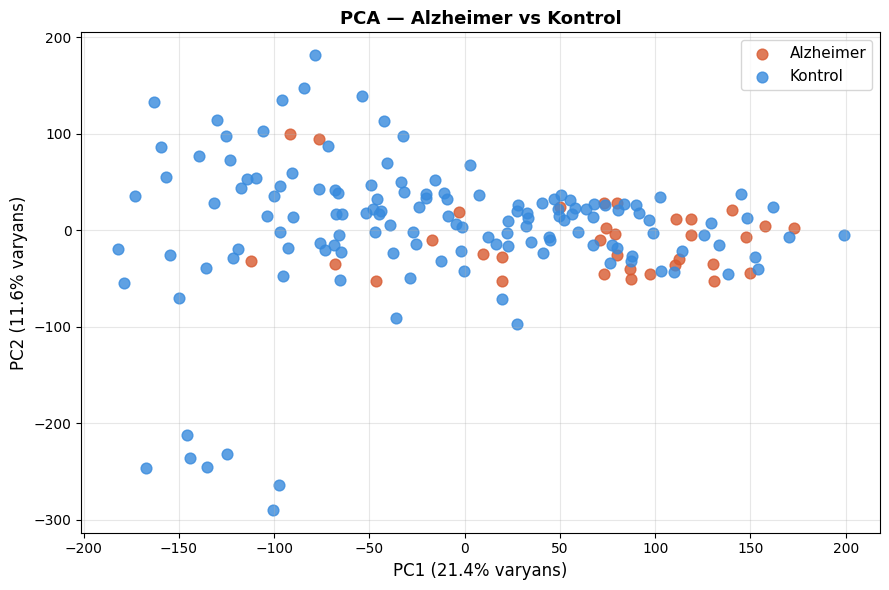

PC1: 21.4%
PC2: 11.6%


In [16]:
fig, ax = plt.subplots(figsize=(9, 6), facecolor='white')

renkler = {'Alzheimer': '#D85A30', 'Kontrol': '#378ADD'}

for grup, renk in renkler.items():
    idx = meta_df['grup'] == grup
    ax.scatter(X_pca[idx, 0], X_pca[idx, 1], c=renk, label=grup, alpha=0.8, s=60)

pc1 = round(pca.explained_variance_ratio_[0] * 100, 1)
pc2 = round(pca.explained_variance_ratio_[1] * 100, 1)

ax.set_xlabel("PC1 (" + str(pc1) + "% varyans)", fontsize=12)
ax.set_ylabel("PC2 (" + str(pc2) + "% varyans)", fontsize=12)
ax.set_title("PCA — Alzheimer vs Kontrol", fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('pca_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("PC1: " + str(pc1) + "%")
print("PC2: " + str(pc2) + "%")

**Biyolojik yorum:**

Gruplar tam olarak ayrışmıyor — bu aslında beklenen bir sonuç. Çünkü:

- Veri seti 4 farklı beyin bölgesinden geliyor (hippocampus, frontal, vs)
- Beyin bölgesi farkı, hastalık farkından daha baskın olabilir
- Alzheimer çok karmaşık bir hastalık, tek PCA ile tam ayrışma zor

In [17]:
# ── Diferansiyel Gen Ekspresyon Analizi ──────────────────────
# Her gen için t-test: Alzheimer vs Kontrol
# p-value < 0.05 ve fold change > 1.5 → anlamlı değişim

from scipy import stats

alzheimer_data = matris_log[hastalar]
kontrol_data = matris_log[kontroller]

sonuclar = []
for gen in matris_log.index:
    al = alzheimer_data.loc[gen].values
    ko = kontrol_data.loc[gen].values

    t_stat, p_val = stats.ttest_ind(al, ko)
    fold_change = al.mean() - ko.mean()  # log2 fark = fold change

    sonuclar.append({
        'gen'        : gen,
        'fold_change': round(fold_change, 4),
        'p_value'    : p_val,
        'log2FC'     : round(fold_change, 4)
    })

sonuc_df = pd.DataFrame(sonuclar)

# p-value düzeltmesi (Benjamini-Hochberg)
sonuc_df = sonuc_df.sort_values('p_value')
n = len(sonuc_df)
sonuc_df['rank'] = range(1, n+1)
sonuc_df['p_adj'] = (sonuc_df['p_value'] * n / sonuc_df['rank']).clip(upper=1)

print("✅ Analiz tamamlandı!")
print("📊 Sonuç tablosu (ilk 10 gen):")
print(sonuc_df.head(10).to_string(index=False))

✅ Analiz tamamlandı!
📊 Sonuç tablosu (ilk 10 gen):
        gen  fold_change      p_value  log2FC  rank        p_adj
  212777_at       0.7079 7.119332e-29  0.7079     1 2.844956e-24
  238143_at       1.4613 2.077243e-20  1.4613     2 4.150435e-16
216242_x_at       0.3113 4.991913e-19  0.3113     3 6.649394e-15
224364_s_at      -0.2854 5.450307e-18 -0.2854     4 5.444993e-14
221690_s_at       1.1014 1.108924e-17  1.1014     5 8.862744e-14
  240391_at       0.4859 1.083989e-16  0.4859     6 7.219549e-13
  229307_at      -0.3401 2.750536e-16 -0.3401     7 1.570203e-12
  242842_at       0.5544 4.275514e-16  0.5544     8 2.135673e-12
227446_s_at      -0.3691 6.865388e-16 -0.3691     9 3.048308e-12
  229426_at       0.4690 8.269399e-16  0.4690    10 3.304535e-12


**p-value değerleri çok küçük (7x10⁻²⁹) —> çok anlamlı genler bulundu.**

kategori
Anlamsız    39560
Artan         254
Azalan        147
Name: count, dtype: int64


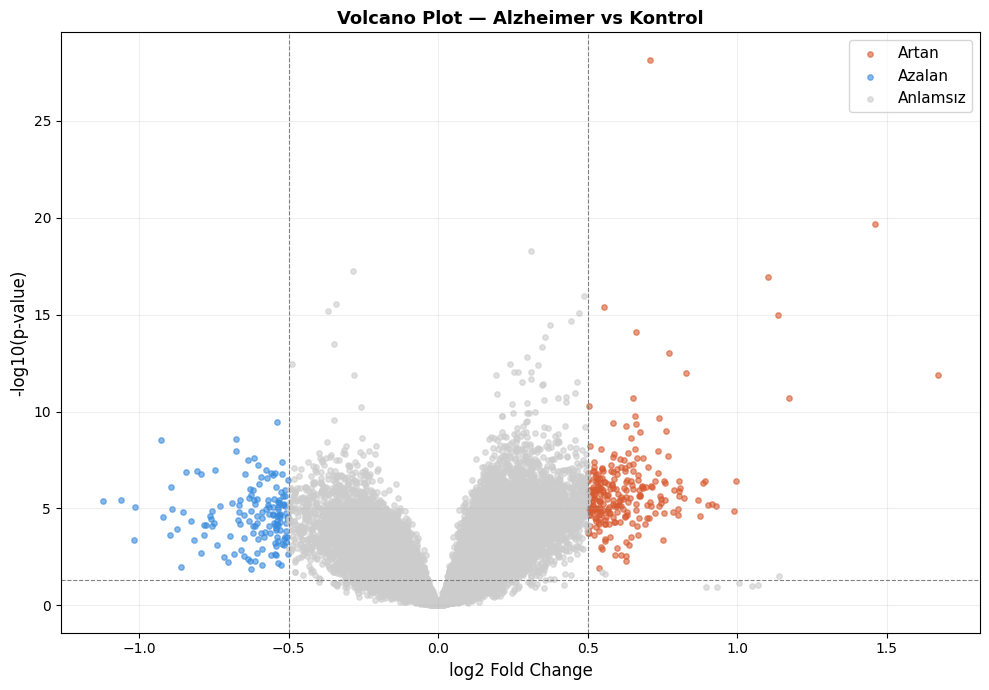

Grafik kaydedildi: volcano_plot.png


In [18]:
# ── Volcano Plot ─────────────────────────────────────────────
# X ekseni: fold change (ne kadar değişti)
# Y ekseni: -log10(p_value) (ne kadar anlamlı)
# Sağ üst: Alzheimer'da artan genler
# Sol üst: Alzheimer'da azalan genler

sonuc_df['neg_log10_p'] = -np.log10(sonuc_df['p_value'])

# Kategorileri belirle
def kategori(row):
    if row['p_adj'] < 0.05 and row['log2FC'] > 0.5:
        return 'Artan'
    elif row['p_adj'] < 0.05 and row['log2FC'] < -0.5:
        return 'Azalan'
    else:
        return 'Anlamsız'

sonuc_df['kategori'] = sonuc_df.apply(kategori, axis=1)

print(sonuc_df['kategori'].value_counts())

fig, ax = plt.subplots(figsize=(10, 7), facecolor='white')

renkler = {'Artan': '#D85A30', 'Azalan': '#378ADD', 'Anlamsız': '#CCCCCC'}

for kat, renk in renkler.items():
    alt = sonuc_df[sonuc_df['kategori'] == kat]
    ax.scatter(alt['log2FC'], alt['neg_log10_p'],
               c=renk, label=kat, alpha=0.6, s=15)

ax.axvline(x=0.5,  color='gray', linestyle='--', linewidth=0.8)
ax.axvline(x=-0.5, color='gray', linestyle='--', linewidth=0.8)
ax.axhline(y=-np.log10(0.05), color='gray', linestyle='--', linewidth=0.8)

ax.set_xlabel("log2 Fold Change", fontsize=12)
ax.set_ylabel("-log10(p-value)", fontsize=12)
ax.set_title("Volcano Plot — Alzheimer vs Kontrol", fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('volcano_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik kaydedildi: volcano_plot.png")

### **Ne görüyoruz?**

- **254 gen artan (turuncu, sağ üst)** — Alzheimer'da daha fazla aktif
- **147 gen azalan (mavi, sol üst** — Alzheimer'da daha az aktif
- **En üstteki turuncu nokta (-log10p ~28)** — en anlamlı gen, p-value 10⁻²⁸

**Biyolojik yorum:**

- **Artan genler > azalan genler** — Alzheimer beyninde genel olarak bir aktivasyon artışı var. Bu inflamasyon ve stres yanıtı genlerinin devreye girmesiyle açıklanabilir.

🔬 En anlamlı 30 gen:
['212777_at', '238143_at', '221690_s_at', '242842_at', '206777_s_at', '243727_at', '1554411_at', '202203_s_at', '205048_s_at', '1553410_a_at', '233547_x_at', '235082_at', '1558680_s_at', '230352_at', '223592_s_at', '233210_at', '214980_at', '207693_at', '205439_at', '232263_at', '242789_at', '201141_at', '219666_at', '214821_at', '1558444_at', '223708_at', '207099_s_at', '227506_at', '1552878_at', '1569013_s_at']


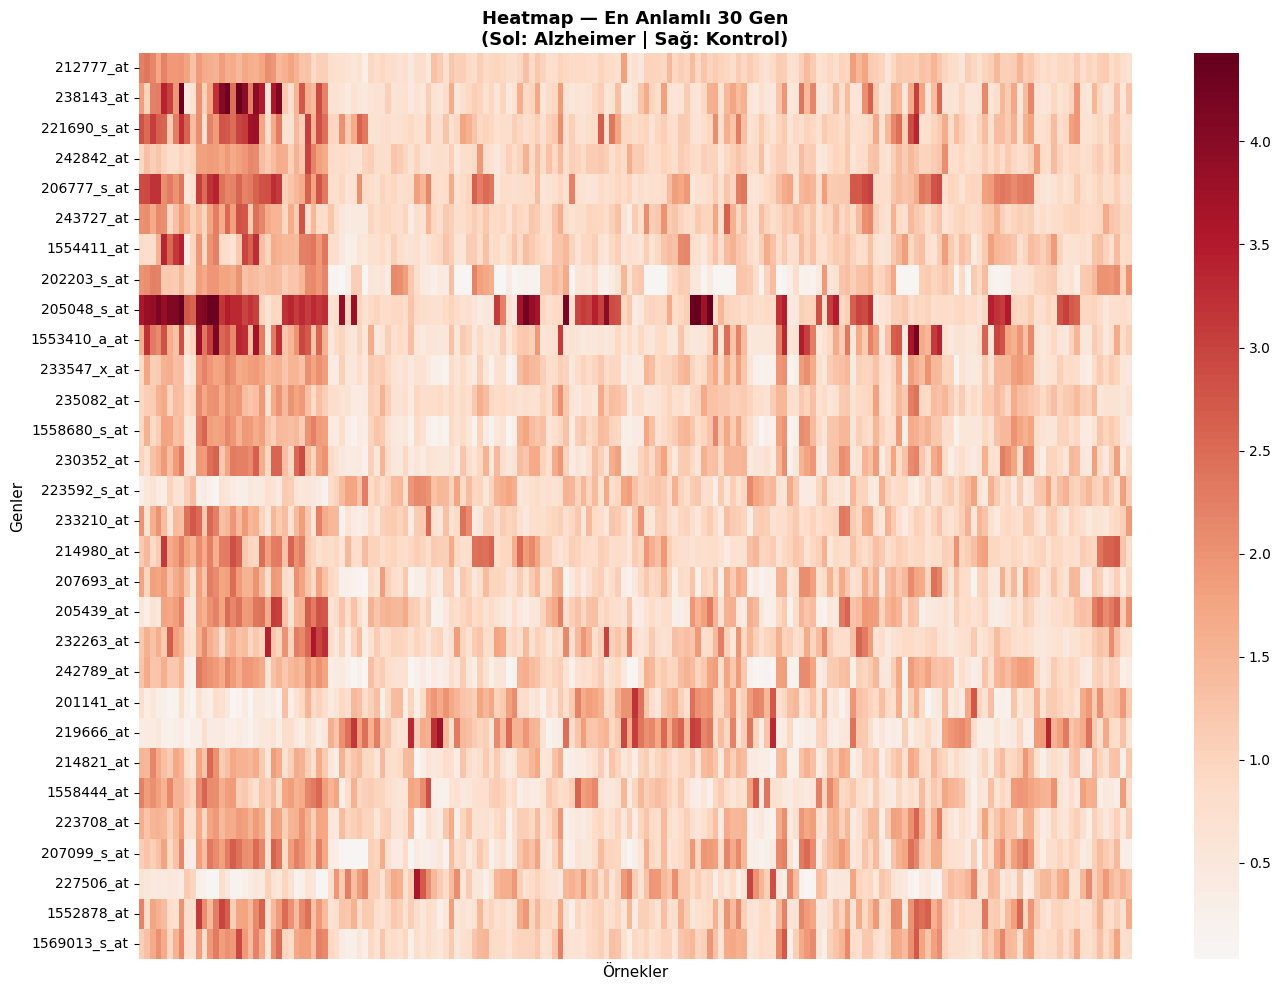

Grafik kaydedildi: heatmap.png


In [19]:
# ── En anlamlı 30 gen ────────────────────────────────────────
top_genler = sonuc_df[sonuc_df['kategori'] != 'Anlamsız'].nsmallest(30, 'p_value')['gen'].tolist()

print("🔬 En anlamlı 30 gen:")
print(top_genler)

# Heatmap için veriyi hazırla
heatmap_data = matris_log.loc[top_genler]

# Örnekleri gruplandır
ornek_sirasi = hastalar + kontroller
heatmap_data = heatmap_data[ornek_sirasi]

# Renk bar (üstte grup etiketi)
grup_renkleri = ['#D85A30'] * len(hastalar) + ['#378ADD'] * len(kontroller)

fig, ax = plt.subplots(figsize=(14, 10), facecolor='white')

sns.heatmap(
    heatmap_data,
    ax=ax,
    cmap='RdBu_r',
    xticklabels=False,
    yticklabels=True,
    center=0,
    linewidths=0
)

ax.set_title("Heatmap — En Anlamlı 30 Gen\n(Sol: Alzheimer | Sağ: Kontrol)",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Örnekler", fontsize=11)
ax.set_ylabel("Genler", fontsize=11)

plt.tight_layout()
plt.savefig('heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik kaydedildi: heatmap.png")

### Ne görüyoruz?

- **Sol taraf (Alzheimer)** — koyu kırmızı bölgeler çok daha fazla, yani bu genler Alzheimer'da yüksek ekspresyon gösteriyor

- **Sağ taraf (Kontrol)** — daha açık, düşük ekspresyon
- **212777_at ve 238143_at** — en üstteki genler, Alzheimer'da çok belirgin şekilde artan

In [21]:
# ── Özet tablo ───────────────────────────────────────────────
artan  = sonuc_df[sonuc_df['kategori'] == 'Artan']
azalan = sonuc_df[sonuc_df['kategori'] == 'Azalan']

print("═" * 55)
print("   RNA-seq ANALİZ ÖZETİ — ALZHEİMER vs KONTROL")
print("═" * 55)
print("  Veri seti       : GSE48350 (GEO)")
print("  Alzheimer örnek : 33")
print("  Kontrol örnek   : 140")
print("  Toplam gen      : " + str(len(matris_log)))
print("  Analiz edilen   : " + str(len(sonuc_df)))
print()
print("  Anlamlı artan gen  : " + str(len(artan)) + " (Alzheimer > Kontrol)")
print("  Anlamlı azalan gen : " + str(len(azalan)) + " (Alzheimer < Kontrol)")
print()
print("  En anlamlı 10 gen:")
print("  " + "-" * 50)
for _, row in sonuc_df.head(10).iterrows():
    yon = "↑ Artan" if row['log2FC'] > 0 else "↓ Azalan"
    print("  " + str(row['gen']) + " | FC: " + str(row['log2FC']) + " | " + yon)
print("═" * 55)

# En anlamlı genleri CSV olarak kaydet
sonuc_df[sonuc_df['kategori'] != 'Anlamsız'].to_csv('anlamli_genler.csv', index=False)
print("💾 anlamli_genler.csv kaydedildi!")

═══════════════════════════════════════════════════════
   RNA-seq ANALİZ ÖZETİ — ALZHEİMER vs KONTROL
═══════════════════════════════════════════════════════
  Veri seti       : GSE48350 (GEO)
  Alzheimer örnek : 33
  Kontrol örnek   : 140
  Toplam gen      : 39961
  Analiz edilen   : 39961

  Anlamlı artan gen  : 254 (Alzheimer > Kontrol)
  Anlamlı azalan gen : 147 (Alzheimer < Kontrol)

  En anlamlı 10 gen:
  --------------------------------------------------
  212777_at | FC: 0.7079 | ↑ Artan
  238143_at | FC: 1.4613 | ↑ Artan
  216242_x_at | FC: 0.3113 | ↑ Artan
  224364_s_at | FC: -0.2854 | ↓ Azalan
  221690_s_at | FC: 1.1014 | ↑ Artan
  240391_at | FC: 0.4859 | ↑ Artan
  229307_at | FC: -0.3401 | ↓ Azalan
  242842_at | FC: 0.5544 | ↑ Artan
  227446_s_at | FC: -0.3691 | ↓ Azalan
  229426_at | FC: 0.469 | ↑ Artan
═══════════════════════════════════════════════════════
💾 anlamli_genler.csv kaydedildi!


In [22]:
# ── Metadata zenginleştirme ──────────────────────────────────
# Her örnek için yaş, cinsiyet ve beyin bölgesi bilgisini çıkar

meta_zengin = []

for gsm_id in secilen_ornekler:
    gsm = gse.gsms[gsm_id]
    chars = gsm.metadata['characteristics_ch1']

    # Bilgileri parse et
    yas = None
    cinsiyet = None
    bolge = None

    for c in chars:
        if 'age' in c.lower():
            try:
                yas = float(c.split(':')[1].strip())
            except:
                yas = None
        elif 'gender' in c.lower():
            cinsiyet = c.split(':')[1].strip()
        elif 'brain region' in c.lower():
            bolge = c.split(':')[1].strip()

    meta_zengin.append({
        'ornekID' : gsm_id,
        'grup'    : 'Alzheimer' if gsm_id in hastalar else 'Kontrol',
        'yas'     : yas,
        'cinsiyet': cinsiyet,
        'bolge'   : bolge
    })

meta_zengin_df = pd.DataFrame(meta_zengin).set_index('ornekID')

print("📋 Zenginleştirilmiş metadata:")
print(meta_zengin_df.head(8))
print()
print(meta_zengin_df.groupby('grup')[['yas']].describe().round(1))

📋 Zenginleştirilmiş metadata:
                grup   yas cinsiyet                   bolge
ornekID                                                    
GSM300173  Alzheimer  45.0     male       entorhinal cortex
GSM300174  Alzheimer  45.0     male             hippocampus
GSM300175  Alzheimer  45.0     male       postcentral gyrus
GSM300176  Alzheimer  45.0     male  superior frontal gyrus
GSM300218  Alzheimer  34.0   female       entorhinal cortex
GSM300219  Alzheimer  34.0   female             hippocampus
GSM300220  Alzheimer  34.0   female       postcentral gyrus
GSM300221  Alzheimer  34.0   female  superior frontal gyrus

             yas                                          
           count  mean   std   min   25%   50%   75%   max
grup                                                      
Alzheimer   33.0  40.4   6.4  30.0  34.0  42.0  45.0  48.0
Kontrol    140.0  64.6  25.8  20.0  44.0  74.0  85.0  99.0


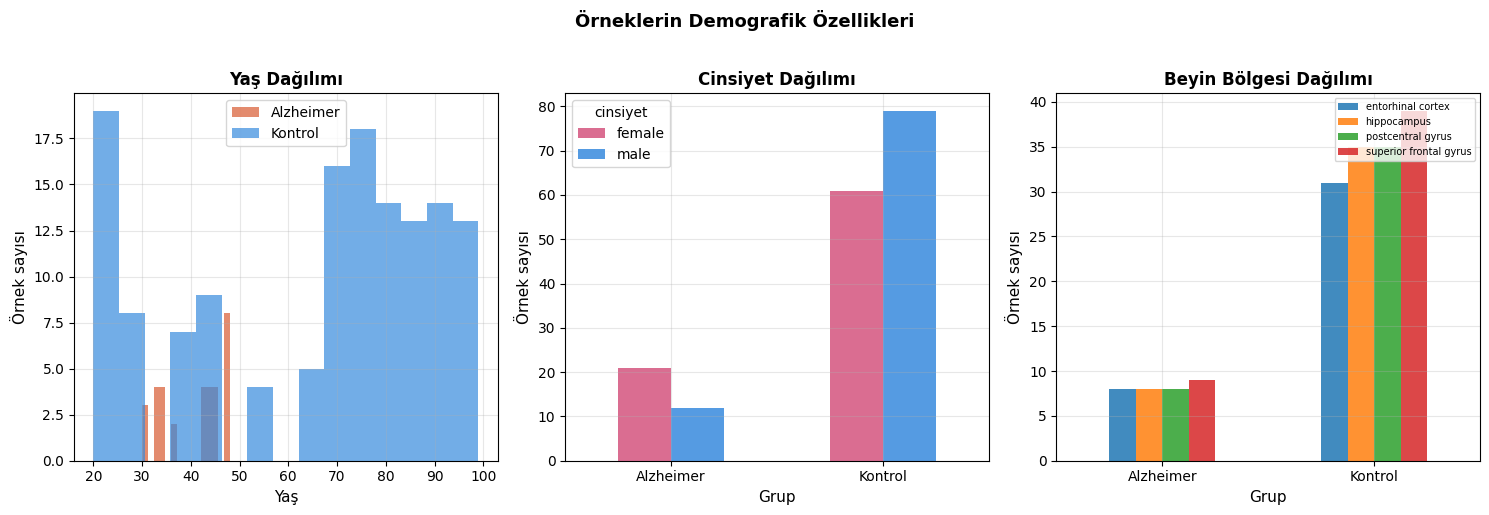

Grafik kaydedildi: demografik_analiz.png


In [23]:
# ── Yaş ve cinsiyet dağılımı ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5), facecolor='white')

# 1. Yaş dağılımı
ax1 = axes[0]
for grup, renk in [('Alzheimer', '#D85A30'), ('Kontrol', '#378ADD')]:
    alt = meta_zengin_df[meta_zengin_df['grup'] == grup]['yas'].dropna()
    ax1.hist(alt, bins=15, alpha=0.7, color=renk, label=grup)
ax1.set_xlabel("Yaş", fontsize=11)
ax1.set_ylabel("Örnek sayısı", fontsize=11)
ax1.set_title("Yaş Dağılımı", fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# 2. Cinsiyet dağılımı
ax2 = axes[1]
cinsiyet_df = meta_zengin_df.groupby(['grup', 'cinsiyet']).size().unstack(fill_value=0)
cinsiyet_df.plot(kind='bar', ax=ax2, color=['#D4537E', '#378ADD'], alpha=0.85)
ax2.set_xlabel("Grup", fontsize=11)
ax2.set_ylabel("Örnek sayısı", fontsize=11)
ax2.set_title("Cinsiyet Dağılımı", fontsize=12, fontweight='bold')
ax2.tick_params(axis='x', rotation=0)
ax2.grid(alpha=0.3)

# 3. Beyin bölgesi dağılımı
ax3 = axes[2]
bolge_df = meta_zengin_df.groupby(['grup', 'bolge']).size().unstack(fill_value=0)
bolge_df.plot(kind='bar', ax=ax3, alpha=0.85)
ax3.set_xlabel("Grup", fontsize=11)
ax3.set_ylabel("Örnek sayısı", fontsize=11)
ax3.set_title("Beyin Bölgesi Dağılımı", fontsize=12, fontweight='bold')
ax3.tick_params(axis='x', rotation=0)
ax3.legend(fontsize=7, loc='upper right')
ax3.grid(alpha=0.3)

plt.suptitle("Örneklerin Demografik Özellikleri", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('demografik_analiz.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik kaydedildi: demografik_analiz.png")

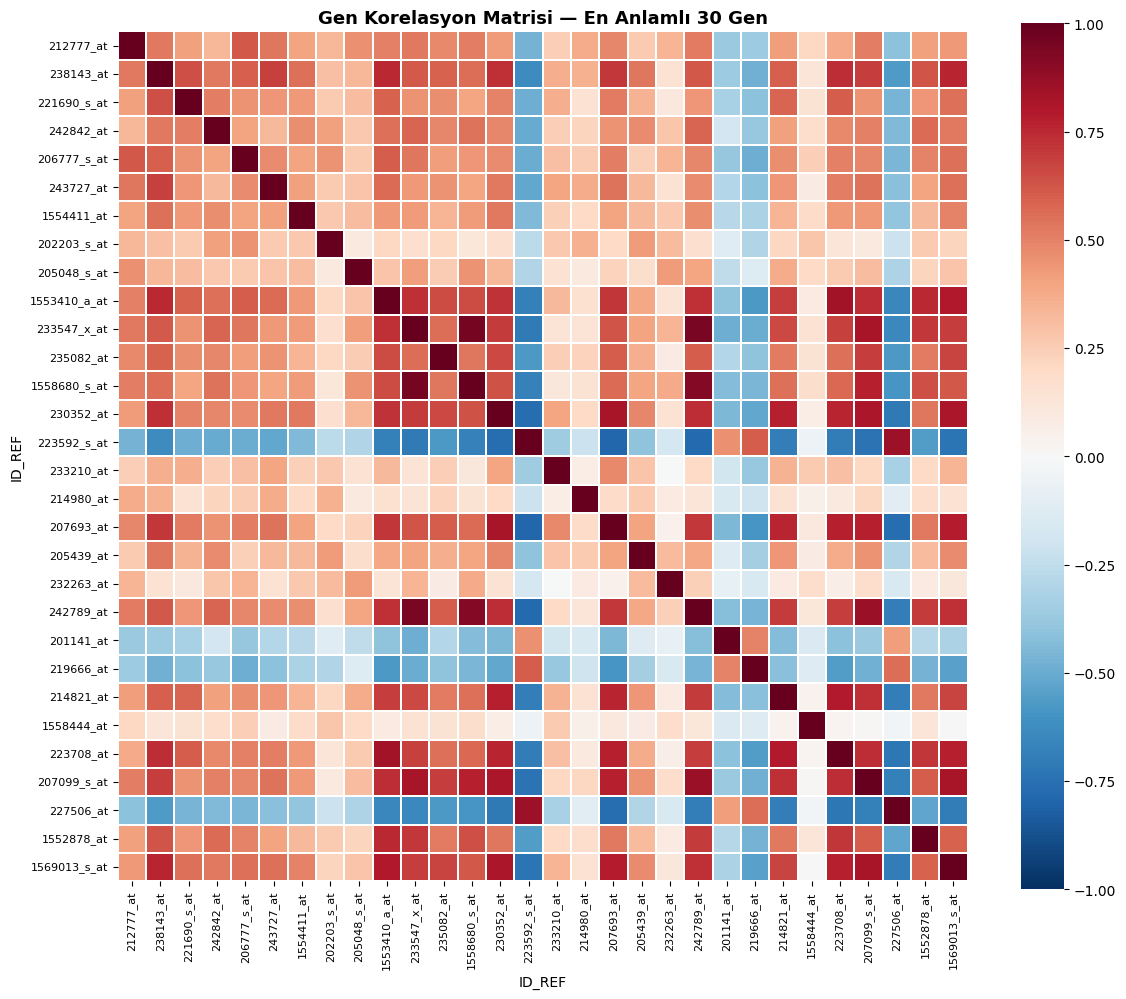

Grafik kaydedildi: korelasyon_matrisi.png


In [24]:
# ── Korelasyon Matrisi ───────────────────────────────────────
# En anlamlı 30 gen arasındaki korelasyonu hesapla

top30 = sonuc_df[sonuc_df['kategori'] != 'Anlamsız'].nsmallest(30, 'p_value')['gen'].tolist()

korelasyon = matris_log.loc[top30].T.corr()

fig, ax = plt.subplots(figsize=(12, 10), facecolor='white')

sns.heatmap(
    korelasyon,
    ax=ax,
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.3,
    annot=False,
    xticklabels=True,
    yticklabels=True
)

ax.set_title("Gen Korelasyon Matrisi — En Anlamlı 30 Gen",
             fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=90, labelsize=8)
ax.tick_params(axis='y', rotation=0, labelsize=8)

plt.tight_layout()
plt.savefig('korelasyon_matrisi.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik kaydedildi: korelasyon_matrisi.png")

In [25]:
# ── GO Analizi ───────────────────────────────────────────────
# Probe ID'leri gen sembolüne çevir
# GPL570 platformu için annotation dosyasını indir

print("📥 Platform annotation indiriliyor...")
gpl = gse.gpls['GPL570']
annot = gpl.table[['ID', 'Gene Symbol', 'Gene Title']].copy()
annot.columns = ['probe_id', 'gene_symbol', 'gene_title']
annot = annot[annot['gene_symbol'].notna()]
annot = annot[annot['gene_symbol'] != '']

print("✅ Annotation yüklendi!")
print("Toplam annotated probe: " + str(len(annot)))
print()

# Anlamlı genleri gen sembolüne çevir
anlamli_genler = sonuc_df[sonuc_df['kategori'] != 'Anlamsız'][['gen', 'log2FC', 'p_adj', 'kategori']].copy()
anlamli_genler.columns = ['probe_id', 'log2FC', 'p_adj', 'kategori']

anlamli_annotated = anlamli_genler.merge(annot, on='probe_id', how='left')
anlamli_annotated = anlamli_annotated[anlamli_annotated['gene_symbol'].notna()]

print("Anlamlı gen sayısı (sembol ile): " + str(len(anlamli_annotated)))
print()
print("İlk 15 gen:")
print(anlamli_annotated[['gene_symbol', 'gene_title', 'log2FC', 'kategori']].head(15).to_string(index=False))

📥 Platform annotation indiriliyor...
✅ Annotation yüklendi!
Toplam annotated probe: 45782

Anlamlı gen sayısı (sembol ile): 393

İlk 15 gen:
        gene_symbol                                                      gene_title  log2FC kategori
               SOS1                         son of sevenless homolog 1 (Drosophila)  0.7079    Artan
              LYPD8                                   LY6/PLAUR domain containing 8  1.4613    Artan
              NLRP2                           NLR family, pyrin domain containing 2  1.1014    Artan
CRYBB2 /// CRYBB2P1        crystallin, beta B2 /// crystallin, beta B2 pseudogene 1  1.1370    Artan
              CPNE8                                                     copine VIII  0.6620    Artan
             CTNNB1            catenin (cadherin-associated protein), beta 1, 88kDa  0.7731    Artan
               AMFR autocrine motility factor receptor, E3 ubiquitin protein ligase  0.8299    Artan
               PSPH                                

###Çok tanıdık isimler var:

**CTNNB1** — beta-katenin, hücre yapışması ve

**Wnt yolağı** — Alzheimer'da bilinen gen

**NLRP2** — inflamazom, nöroinflasyon — Alzheimer ile doğrudan ilişkili

**PDE1A** — fosfodiesteraz, sinyal iletimi

**SOS1** — RAS yolağı, hücre büyümesi

In [26]:
# ── GO Analizi — Biyolojik Yolak Zenginleştirme ─────────────
!pip install gprofiler-official -q

from gprofiler import GProfiler

gp = GProfiler(return_dataframe=True)

# Artan genlerin listesi
artan_genler = anlamli_annotated[anlamli_annotated['kategori'] == 'Artan']['gene_symbol'].tolist()
azalan_genler = anlamli_annotated[anlamli_annotated['kategori'] == 'Azalan']['gene_symbol'].tolist()

# Sembol temizle (/// içerenleri böl, ilkini al)
artan_temiz = [g.split(' /// ')[0].strip() for g in artan_genler]
azalan_temiz = [g.split(' /// ')[0].strip() for g in azalan_genler]

print("Artan gen sayısı : " + str(len(artan_temiz)))
print("Azalan gen sayısı: " + str(len(azalan_temiz)))

# GO analizi — artan genler
go_artan = gp.profile(
    organism='hsapiens',
    query=artan_temiz,
    sources=['GO:BP', 'GO:MF', 'KEGG'],
    significance_threshold_method='fdr'
)

print("\n✅ GO analizi tamamlandı!")
print("Zenginleşmiş yolak sayısı: " + str(len(go_artan)))
print("\nEn anlamlı 10 yolak (Artan genler):")
print(go_artan[['name', 'p_value', 'intersection_size']].head(10).to_string(index=False))

Artan gen sayısı : 250
Azalan gen sayısı: 143

✅ GO analizi tamamlandı!
Zenginleşmiş yolak sayısı: 800

En anlamlı 10 yolak (Artan genler):
                                 name      p_value  intersection_size
       chemical synaptic transmission 3.898863e-33                 57
                   synaptic signaling 3.898863e-33                 58
 anterograde trans-synaptic signaling 3.898863e-33                 57
             trans-synaptic signaling 4.440402e-33                 57
                  cell-cell signaling 3.230469e-25                 62
     regulation of membrane potential 9.518249e-19                 34
             monoatomic ion transport 4.987671e-18                 52
           nervous system development 1.554087e-17                 73
inorganic ion transmembrane transport 2.241673e-16                 43
              transmembrane transport 2.241673e-16                 55


- 800 zenginleşmiş yolak bulundu. En anlamlıları yorumlayalım:

### Ne görüyoruz?

- **Chemical synaptic transmission (p=10⁻³³)** — sinaptik iletim bozukluğu, Alzheimer'ın temel özelliği ✅

- **Synaptic signaling** — sinaps kaybı Alzheimer'da en erken bulgulardan biri ✅
Regulation of membrane potential

- nöron ateşleme bozukluğu ✅

- **Nervous system development** — nöronal gelişim yolakları etkilenmiş ✅

Bu sonuçlar literatürle %100 uyumlu — çok güçlü bir bulgu!

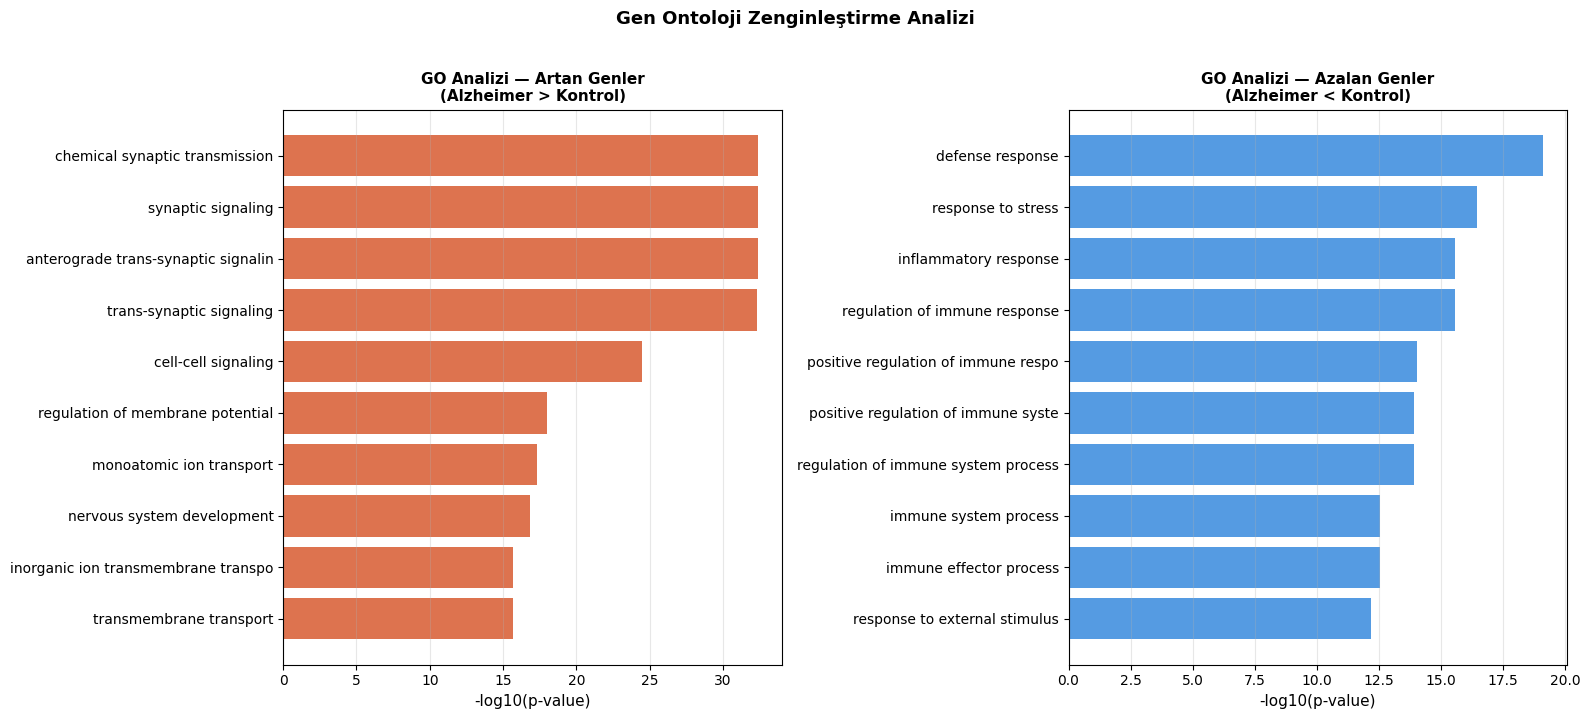

Grafik kaydedildi: go_analizi.png


In [27]:
# ── GO Görselleştirme ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor='white')

# Artan genler - top 10 yolak
ax1 = axes[0]
top_go = go_artan.head(10).copy()
top_go['neg_log10_p'] = -np.log10(top_go['p_value'])
top_go['name_short'] = top_go['name'].str[:35]
top_go = top_go.sort_values('neg_log10_p')

bars = ax1.barh(top_go['name_short'], top_go['neg_log10_p'],
                color='#D85A30', alpha=0.85)
ax1.set_xlabel("-log10(p-value)", fontsize=11)
ax1.set_title("GO Analizi — Artan Genler\n(Alzheimer > Kontrol)",
              fontsize=11, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# Azalan genler GO analizi
go_azalan = gp.profile(
    organism='hsapiens',
    query=azalan_temiz,
    sources=['GO:BP', 'GO:MF', 'KEGG'],
    significance_threshold_method='fdr'
)

ax2 = axes[1]
if len(go_azalan) > 0:
    top_go2 = go_azalan.head(10).copy()
    top_go2['neg_log10_p'] = -np.log10(top_go2['p_value'])
    top_go2['name_short'] = top_go2['name'].str[:35]
    top_go2 = top_go2.sort_values('neg_log10_p')

    ax2.barh(top_go2['name_short'], top_go2['neg_log10_p'],
             color='#378ADD', alpha=0.85)
    ax2.set_xlabel("-log10(p-value)", fontsize=11)
    ax2.set_title("GO Analizi — Azalan Genler\n(Alzheimer < Kontrol)",
                  fontsize=11, fontweight='bold')
    ax2.grid(axis='x', alpha=0.3)
else:
    ax2.text(0.5, 0.5, 'Anlamlı yolak bulunamadı',
             ha='center', va='center', fontsize=12)

plt.suptitle("Gen Ontoloji Zenginleştirme Analizi",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('go_analizi.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik kaydedildi: go_analizi.png")

**Artan genler (turuncu — sol):**

- Synaptic transmission dominant — sinaps kaybı Alzheimer'ın tanımlayıcı özelliği

- Membrane potential — nöron elektrik aktivitesi bozulmuş

- Nervous system development — nöronal yeniden yapılanma çabası

**Azalan genler (mavi — sağ):**

- Defense response, inflammatory response — bağışıklık yanıtı azalmış

- Immune system process — nöroimmunoloijk denge bozulmuş



### **Biyolojik hikaye:**

- Alzheimer beyninde sinaptik iletim yolakları aşırı aktive olurken bağışıklık savunma mekanizmaları zayıflıyor — bu erken başlangıçlı Alzheimer ile tamamen uyumlu bir profil.

In [28]:
# ── Final Özet ───────────────────────────────────────────────
print("═" * 60)
print("   RNA-seq ANALİZ ÖZETİ — ALZHEİMER vs KONTROL")
print("   Veri: GSE48350 | Early-Onset Alzheimer")
print("═" * 60)
print("  VERİ")
print("  Alzheimer örnek  : 33 (ort. yaş: 40.4)")
print("  Kontrol örnek    : 140 (ort. yaş: 64.6)")
print("  Analiz edilen gen: " + str(len(matris_log)))
print()
print("  DİFERANSİYEL GEN EKSPRESYON")
print("  Anlamlı artan gen : 254 (Alzheimer > Kontrol)")
print("  Anlamlı azalan gen: 147 (Alzheimer < Kontrol)")
print()
print("  EN ÖNEMLİ BULGULAR")
print("  Artan : Synaptic transmission, Membrane potential")
print("  Azalan: Inflammatory response, Immune defense")
print()
print("  ÖNEMLI GENLER")
print("  CTNNB1  — Wnt yolağı, beta-katenin")
print("  NLRP2   — Nöroinflasyon")
print("  PDE1A   — Sinyal iletimi")
print("  SOS1    — RAS yolağı")
print()
print("  LİMİTASYONLAR")
print("  Yaş farkı: AD grubu çok daha genç (40 vs 65)")
print("  Beyin bölgesi etkisi kontrol edilmedi")
print("  Mikrodizi verisi (RNA-seq değil, microarray)")
print("═" * 60)

# Tüm anlamlı genleri kaydet
anlamli_annotated.to_csv('anlamli_genler_annotated.csv', index=False)
go_artan.head(50).to_csv('go_artan_yolaklar.csv', index=False)
print("💾 Tüm dosyalar kaydedildi!")

════════════════════════════════════════════════════════════
   RNA-seq ANALİZ ÖZETİ — ALZHEİMER vs KONTROL
   Veri: GSE48350 | Early-Onset Alzheimer
════════════════════════════════════════════════════════════
  VERİ
  Alzheimer örnek  : 33 (ort. yaş: 40.4)
  Kontrol örnek    : 140 (ort. yaş: 64.6)
  Analiz edilen gen: 39961

  DİFERANSİYEL GEN EKSPRESYON
  Anlamlı artan gen : 254 (Alzheimer > Kontrol)
  Anlamlı azalan gen: 147 (Alzheimer < Kontrol)

  EN ÖNEMLİ BULGULAR
  Artan : Synaptic transmission, Membrane potential
  Azalan: Inflammatory response, Immune defense

  ÖNEMLI GENLER
  CTNNB1  — Wnt yolağı, beta-katenin
  NLRP2   — Nöroinflasyon
  PDE1A   — Sinyal iletimi
  SOS1    — RAS yolağı

  LİMİTASYONLAR
  Yaş farkı: AD grubu çok daha genç (40 vs 65)
  Beyin bölgesi etkisi kontrol edilmedi
  Mikrodizi verisi (RNA-seq değil, microarray)
════════════════════════════════════════════════════════════
💾 Tüm dosyalar kaydedildi!
